# Regresión lineal

## Descarga de los datos

In [2]:
!curl -O https://raw.githubusercontent.com/aavelozb/aavelozb.github.io/main/data/passenger_data.txt

  % Total    % Received % Xferd  Average Speed   Time    Time     Time  Current
                                 Dload  Upload   Total   Spent    Left  Speed
100  7200  100  7200    0     0   160k      0 --:--:-- --:--:-- --:--:--  163k


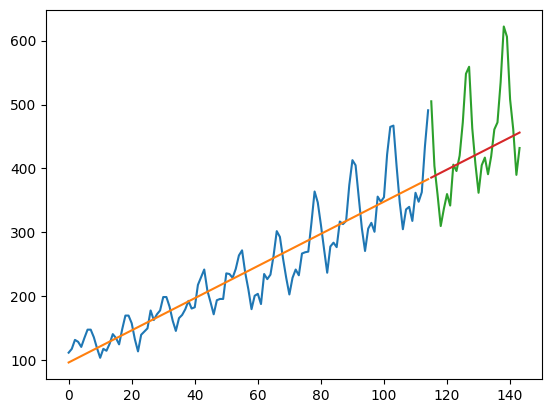

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from numpy.linalg import inv

data = np.loadtxt('passenger_data.txt')

N = data.shape[0]
X = np.zeros((N,2))
X[:,0] = 1
X[:,1] = data[:,0]
y = data[:,1]

# división de los datos train/test
r = 0.8
X_train = X[:int(N*r),:]
y_train = y[:int(N*r)]
X_test = X[int(N*r):,:]
y_test = y[int(N*r):]

theta = inv(X_train.T @ X_train) @ X_train.T @ y_train 

y_train_est = X_train @ theta
y_test_est = X_test @ theta

plt.figure(1)
plt.plot(X_train[:,1], y_train)
plt.plot(X_train[:,1], y_train_est)
plt.plot(X_test[:,1], y_test)
plt.plot(X_test[:,1], y_test_est)
plt.show()



Usando un modelo AR

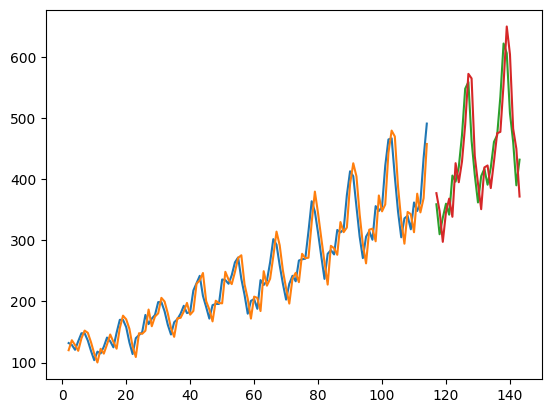

In [7]:
def y2ar(y, time = [], p=2):
    N = len(y)
    Yar = y[p:]
    time = time[p:]
    Xar = np.zeros( (N-p,p) )
    for i in range(p):
        Xar[:,i] = y[p-i-1:N-i-1]
    return Xar, Yar, time

r = 0.8
time_train = data[:int(len(data)*r),0]
data_train = data[:int(len(data)*r),1]
time_test = data[int(len(data)*r):,0]
data_test = data[int(len(data)*r):,1]

X_train, y_train, time_train = y2ar(data_train, time_train, p=2)
X_test, y_test, time_test = y2ar(data_test, time_test, p=2)

theta = inv(X_train.T @ X_train) @ X_train.T @ y_train 

y_train_est = X_train @ theta
y_test_est = X_test @ theta


plt.figure(1)
plt.plot(time_train, y_train)
plt.plot(time_train, y_train_est)
plt.plot(time_test, y_test)
plt.plot(time_test, y_test_est)
plt.show()
